---
**Name : Aashoday S Surwade**\
**Roll No : 24AI126**\
**Class : SE-B AIML**\
**Course : FML**\
**FML Assignment 7**

---

**Problem Statement** :

Implement assignment based on K-Means clustering algorithm
and evaluate the performance,

*Case Study* : Anomaly Detection in Network Security:To detect
unusual or malicious activities (anomalies) in a computer
network by applying unsupervised learning (K-Means
Clustering). The algorithm will help separate normal traffic from
potential attacks or intrusions without relying on labeled data

---

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

# For reproducibility
np.random.seed(42)

In [2]:
# Load Data 
train = pd.read_csv("data/kdd_train.csv")
test = pd.read_csv("data/kdd_test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

df = pd.concat([train, test], axis=0).reset_index(drop=True)

print("Conbined Shape:", df.shape)

df.head()

Train Shape: (125973, 42)
Test Shape: (22544, 42)
Conbined Shape: (148517, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [3]:
# Separate labels and columns
y = df["labels"]
X = df.drop("labels", axis=1)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (148517, 41)
Label Shape: (148517,)


In [4]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
print("categorical columns:", categorical_cols)

categorical columns: Index(['protocol_type', 'service', 'flag'], dtype='object')


In [5]:
# Encode categorical features - One Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols)

print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)

X_encoded.head()

Shape before encoding: (148517, 41)
Shape after encoding: (148517, 122)


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,0,146,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,True,False,False,False,False,False
3,0,232,8153,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
4,0,199,420,0,0,0,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False


In [6]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (148517, 122)


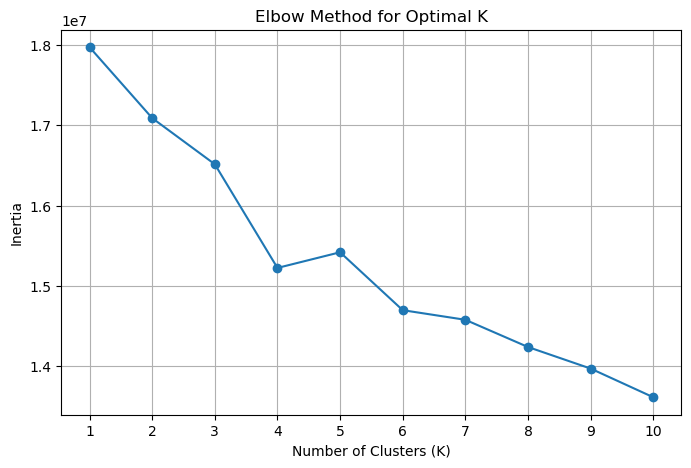

In [7]:
# Elbow method to find optimal k
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xticks(K_range)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

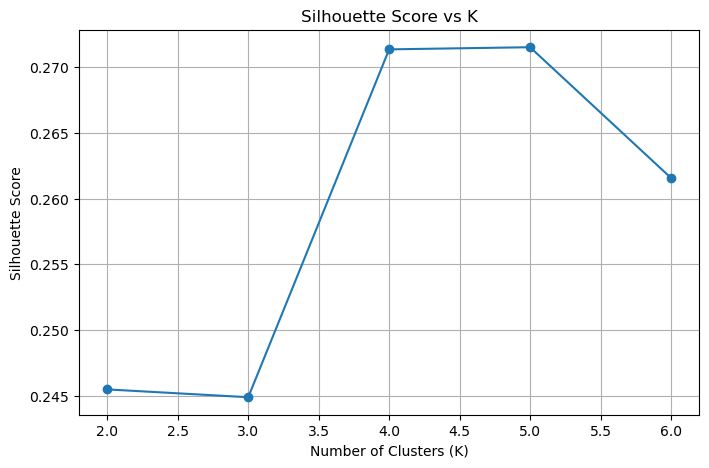

In [9]:
# Silhouette score evaluation
# Take a sample for silhouette evaluation
sample_size = 10000
idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[idx]
sil_scores = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, cluster_labels)
    sil_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2,7), sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.grid(True)
plt.show()

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

# Add labels to dataframe
df["cluster"]= clusters

print("Clustering Complete.")
df['cluster'].value_counts()

Clustering Complete.


cluster
3    62636
0    39949
1    27321
2    18611
Name: count, dtype: int64

In [11]:
# Cross-tab between clusters and actual labels
pd.crosstab(df["cluster"], y)

labels,apache2,back,buffer_overflow,ftp_write,guess_passwd,httptunnel,imap,ipsweep,land,loadmodule,...,smurf,snmpgetattack,snmpguess,spy,teardrop,warezclient,warezmaster,xlock,xsnoop,xterm
cluster,,,,,,,,,,,,,,,,,,,,,
0,42,0,0,0,1,0,6,0,20,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,3532,0,0,...,3186,43,99,0,996,0,0,0,0,0
2,108,9,0,0,64,33,0,482,0,0,...,0,0,0,0,0,2,0,0,0,0
3,78,1174,47,10,399,8,7,64,0,13,...,0,0,0,2,0,994,299,4,1,3


In [12]:
# Convert multi class labels to binary 0 -> Normal | 1 -> Anomaly
binary_y = y.apply(lambda x: 0 if x == "normal" else 1)
print(binary_y.value_counts())

labels
0    78588
1    69929
Name: count, dtype: int64


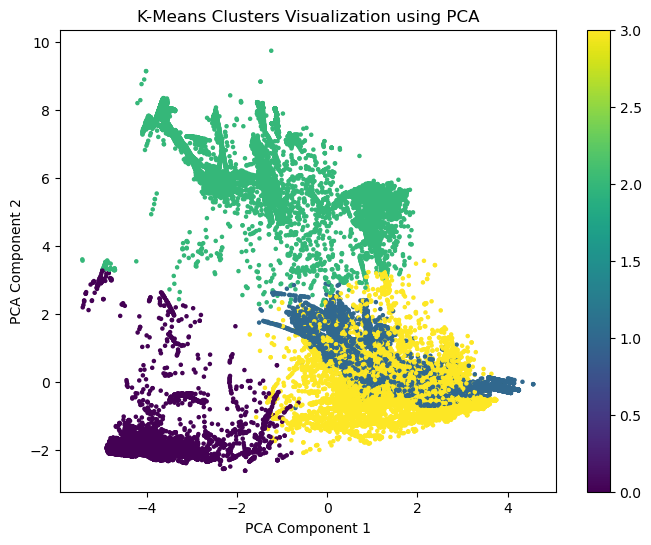

In [13]:
# 2D cluster visualization plot
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], 
                      c=clusters, cmap='viridis', s=5)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters Visualization using PCA")
plt.colorbar(scatter)
plt.show()

In [14]:
# Define normal cluster
normal_cluster = 3

# Create anomaly predictions
y_pred = df['cluster'].apply(lambda x: 0 if x == normal_cluster else 1)

# Check distribution
pd.crosstab(y_pred, binary_y)

labels,0,1
cluster,,
0,59115,3521
1,19473,66408


In [15]:
# Performance matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Confusion matrix
cm = confusion_matrix(binary_y, y_pred)
print("Confusion Matrix:")
print(cm)

# Metrics
accuracy = accuracy_score(binary_y, y_pred)
precision = precision_score(binary_y, y_pred)
recall = recall_score(binary_y, y_pred)
f1 = f1_score(binary_y, y_pred)

print("\nAccuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Confusion Matrix:
[[59115 19473]
 [ 3521 66408]]

Accuracy: 0.8452
Precision: 0.7733
Recall: 0.9496
F1 Score: 0.8524


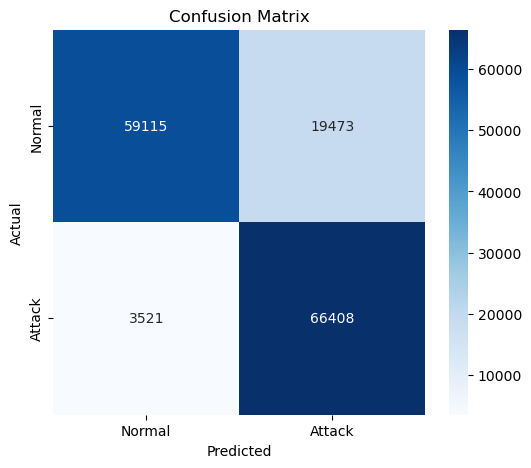

In [16]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Attack'],
            yticklabels=['Normal','Attack'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

---
### Conclusion: 


---